In [1]:
import itertools
import random
from dataclasses import dataclass, field
from typing import Literal, Optional

import cmap
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.optimize import curve_fit

In [2]:
plt.rcParams["axes.ymargin"] = 0
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["legend.edgecolor"] = "None"
plt.rcParams["legend.facecolor"] = "None"

In [3]:
@dataclass
class Plasmid:
    accession: str
    host_phylum: str
    ds_type: set[str] = field(default_factory=set)
    ds_subtype: set[str] = field(default_factory=set)

In [4]:
def compute_iteration_curve(
    plasmids: list[Plasmid],
    ds_level: Literal["type", "subtype"],
    seed: int,
    max_n_plasmids: Optional[int] = None,
) -> list[int]:
    ds_list = [
        plasmid.ds_type if ds_level == "type" else plasmid.ds_subtype
        for plasmid in plasmids
    ]
    random.Random(seed).shuffle(ds_list)
    if max_n_plasmids and len(ds_list) > max_n_plasmids:
        ds_list = ds_list[:max_n_plasmids]
    sampled_ds = set()
    curve_i = []
    for ds in ds_list:
        sampled_ds.update(ds)
        curve_i.append(len(sampled_ds))
    return curve_i


def compute_rarefaction_curve(
    plasmids: list[Plasmid],
    host_phylum: str,
    ds_level: Literal["type", "subtype"],
    n_iterations: int = 500,
    max_n_plasmids: Optional[int] = None,
) -> list[int]:
    curves = []
    plasmids = list(
        filter(
            lambda p: (host_phylum == "all" or p.host_phylum == host_phylum),
            plasmids,
        )
    )
    for i in range(n_iterations):
        curve_i = compute_iteration_curve(plasmids, ds_level, i, max_n_plasmids)
        curves.append(curve_i)
    return np.array(curves).mean(axis=0).tolist()

In [5]:
def heaps_law(n: int, kappa: float, gamma: float) -> float:
    return kappa * n**gamma


def compute_curve_gamma(curve: list[int]) -> float:
    popt, _ = curve_fit(heaps_law, range(1, len(curve) + 1), curve)
    return float(popt[1])

In [6]:
plasmid_dict = {}
for row in pl.read_excel(
    "data/plsdb_plasmid-host_metadata_with_taxonomy.xlsx", infer_schema_length=0
).iter_rows(named=True):
    plasmid_accession = row["plasmid_seqid"]
    plasmid_host_phylum = row["taxonomy_phylum"]
    plasmid_dict[plasmid_accession] = Plasmid(plasmid_accession, plasmid_host_phylum)
excluded_ds = {"MazEF", "Hok/Sok"}
for row in pl.read_excel("data/plsdb_plasmid_defense.xlsx").iter_rows(named=True):
    plasmid_accession = row["plasmid_seqid"]
    if plasmid_accession in plasmid_dict:
        ds_type = row["type"]
        ds_subtype = row["subtype"]
        if ds_type in excluded_ds or ds_subtype in excluded_ds:
            continue
        plasmid_dict[plasmid_accession].ds_type.add(ds_type)
        plasmid_dict[plasmid_accession].ds_subtype.add(ds_subtype)

In [7]:
plasmids = list(plasmid_dict.values())
plasmid_curves_dict = {}
for p, t in itertools.product(
    [
        "all",
        "Pseudomonadota",
        "Bacillota",
        "Bacteroidota",
        "Actinomycetota",
        "Spirochaetota",
        "Cyanobacteriota",
    ],
    ["type", "subtype"],
):
    curve = compute_rarefaction_curve(plasmids, p, t)
    gamma = compute_curve_gamma(curve)
    plasmid_curves_dict[(p, t)] = (curve, gamma)

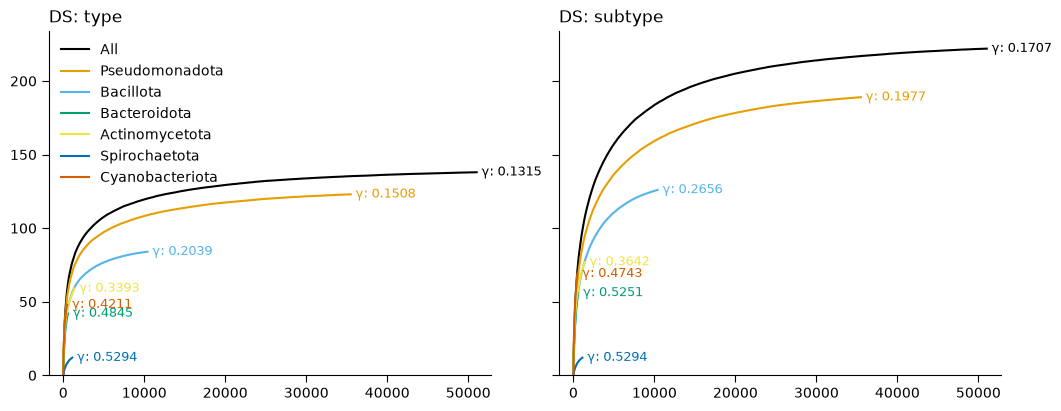

In [10]:
fig, ax = plt.subplots(
    ncols=2, figsize=(10.5, 4), sharex=True, sharey=True, constrained_layout=True
)
max_n_plasmids = 0
max_n_subsystems = 0
colors = cmap.Colormap("okabeito").to_matplotlib().colors
for i, host_phylum in enumerate(
    [
        "all",
        "Pseudomonadota",
        "Bacillota",
        "Bacteroidota",
        "Actinomycetota",
        "Spirochaetota",
        "Cyanobacteriota",
    ]
):
    curve_1 = plasmid_curves_dict[(host_phylum, "type")][0]
    curve_2 = plasmid_curves_dict[(host_phylum, "subtype")][0]
    gamma_1 = plasmid_curves_dict[(host_phylum, "type")][1]
    gamma_2 = plasmid_curves_dict[(host_phylum, "subtype")][1]
    ax[0].plot(curve_1, label=host_phylum.capitalize(), c=colors[i])
    ax[1].plot(curve_2, c=colors[i])
    if len(curve_1) > max_n_plasmids:
        max_n_plasmids = len(curve_1)
    if max(curve_2) > max_n_subsystems:
        max_n_subsystems = max(curve_2)
    ax[0].text(
        len(curve_1) + 600,
        curve_1[-1],
        f"γ: {gamma_1:.4f}",
        ha="left",
        va="center",
        fontsize=9,
        color=colors[i],
    )
    ax[1].text(
        len(curve_2) + 600,
        curve_2[-1],
        f"γ: {gamma_2:.4f}",
        ha="left",
        va="center",
        fontsize=9,
        color=colors[i],
    )
x_padding = max_n_plasmids * 0.035
y_padding = max_n_subsystems * 0.055
ax[0].set_title("DS: type", loc="left")
ax[1].set_title("DS: subtype", loc="left")
ax[0].set_ylim(0, max_n_subsystems + y_padding)
ax[0].set_xlim(-x_padding, max_n_plasmids + x_padding)
ax[0].legend(loc="upper left")
fig.savefig("plots/figS03_A.pdf", dpi=200)

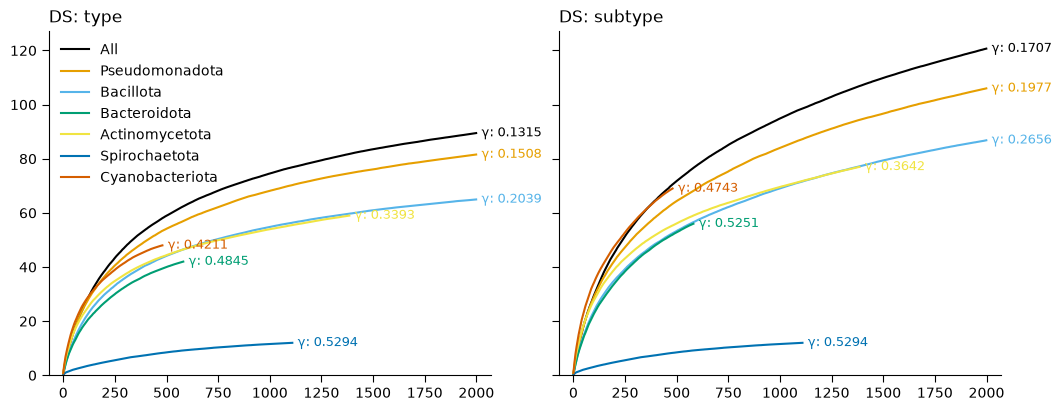

In [11]:
fig, ax = plt.subplots(
    ncols=2, figsize=(10.5, 4), sharex=True, sharey=True, constrained_layout=True
)
max_n_plasmids = 2_000
max_n_subsystems = 0
colors = cmap.Colormap("okabeito").to_matplotlib().colors
for i, host_phylum in enumerate(
    [
        "all",
        "Pseudomonadota",
        "Bacillota",
        "Bacteroidota",
        "Actinomycetota",
        "Spirochaetota",
        "Cyanobacteriota",
    ]
):
    curve_1 = plasmid_curves_dict[(host_phylum, "type")][0][:max_n_plasmids]
    curve_2 = plasmid_curves_dict[(host_phylum, "subtype")][0][:max_n_plasmids]
    gamma_1 = plasmid_curves_dict[(host_phylum, "type")][1]
    gamma_2 = plasmid_curves_dict[(host_phylum, "subtype")][1]
    ax[0].plot(curve_1, label=host_phylum.capitalize(), c=colors[i])
    ax[1].plot(curve_2, c=colors[i])
    if max(curve_2) > max_n_subsystems:
        max_n_subsystems = max(curve_2)
    ax[0].text(
        min(max_n_plasmids, len(curve_1)) + 25,
        curve_1[-1],
        f"γ: {gamma_1:.4f}",
        ha="left",
        va="center",
        fontsize=9,
        color=colors[i],
    )
    ax[1].text(
        min(max_n_plasmids, len(curve_2)) + 25,
        curve_2[-1],
        f"γ: {gamma_2:.4f}",
        ha="left",
        va="center",
        fontsize=9,
        color=colors[i],
    )
x_padding = max_n_plasmids * 0.035
y_padding = max_n_subsystems * 0.055
ax[0].set_title("DS: type", loc="left")
ax[1].set_title("DS: subtype", loc="left")
ax[0].set_ylim(0, max_n_subsystems + y_padding)
ax[0].set_xlim(-x_padding, max_n_plasmids + x_padding)
ax[0].legend(loc="upper left")
fig.savefig("plots/figS03_B.pdf", dpi=200)